In [ ]:
# in this file we have used postgree with the help of docker and then we have tested it by giving maximun no of tokens and 
# checks the llm 

In [1]:
import os
os.environ["LANGCHAIN_TRACING_V2"] = "false"

In [2]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

D:\code floders\PYTHON-5\LANGCHAIN_MODELS\new_environment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
os.environ["OPENROUTER_API_KEY"]="sk-or-v1-8015337cd09edac153f973bc14e0a12f5463a727ccbde806"
model = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    model="openrouter/free",
    temperature=0.7,
)



In [6]:
MAX_TOKENS = 160


In [7]:

def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [8]:
builder = StateGraph(MessagesState)

builder.add_node("call_model",call_model)

builder.add_edge(START,"call_model")


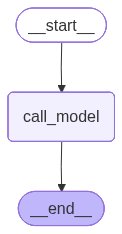

In [12]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [13]:
config = {"configurable":{"thread_id":"chat-1"}}

result = graph.invoke(
    {"messages":[{"role":"user","content":"hi my name is kaunain. "}]},
    config,
    
)
result["messages"][-1].content

Current Token Count -> 10
hi my name is kaunain. 


"\n\nHello, Kaunain! It's nice to meet you. How can I assist you today? 😊\n"

In [14]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 43
hi my name is kaunain. 


Hello, Kaunain! It's nice to meet you. How can I assist you today? 😊

I am learning LangGraph.


"That's great! LangGraph is a powerful tool for building applications with language models that have memory and state. Whether you're working on agents, workflows, or multi-agent systems, I'd be happy to help you with any specific questions or challenges you're facing.\n\nAre you working on:\n- Setting up a basic agent or workflow?\n- Managing state and memory?\n- Creating complex graphs with multiple nodes/edges?\n- Integrating with external tools or APIs?\n- Debugging or optimizing performance?\n\nLet me know what you're working on, and I'll provide guidance or examples! 😊\n"

In [15]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'Short-term memory (STM), often referred to as **primary memory**, is the capacity to hold a small amount of information in an active, readily available state for a **brief period** (seconds to about a minute). It\'s your "mental workspace" for immediate tasks.\n\nHere\'s a breakdown of its key characteristics:\n\n1.  **Duration (How Long It Lasts):**\n    *   **Very Short:** Information typically lasts only **15-30 seconds** without active effort.\n    *   **Decay:** The primary reason forgetting occurs in STM is **decay** – the memory trace simply fades away over time if not rehearsed.\n    *   **Evidence:** Peterson & Peterson\'s famous experiment showed people forgot 3 consonant syllables (like "XKJ") within about 18 seconds when prevented from rehearsing (by counting backwards).\n\n2.  **Capacity (How Much It Holds):**\n    *   **Limited:** STM has a famously small capacity, famously described by George Miller as the **"magic number 7±2"** – meaning most people can hold about **5 

In [16]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


"I don't have access to personal information about users unless you choose to share it with me. If you'd like to tell me your name, I'd be happy to use it when we chat! 😊\n"

In [17]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

hi my name is kaunain. 
------------------------------------------------------------------------------------------------------------------------


Hello, Kaunain! It's nice to meet you. How can I assist you today? 😊

------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That's great! LangGraph is a powerful tool for building applications with language models that have memory and state. Whether you're working on agents, workflows, or multi-agent systems, I'd be happy to help you with any specific questions or challenges you're facing.

Are you working on:
- Setting up a basic agent or workflow?
- Managing state and memory?
- Creating complex graphs with multiple nodes/edges?
- Integrating with external tools or APIs?
- Debugging or optimizing performance?

Let me know what you'